# 🚗 Car Market Trends Analysis with Car Dekho Data
### Project: Vehicle Resale Valuation & Market Dynamics Case Study
**Author:** OSMAN AHMED KHAN

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Set visualization styling
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 11

## Load the Dataset

In [11]:
# Load Car Dekho dataset
df = pd.read_csv('Car Market Trends Analysis with Car Dekho Data.csv')

# Display first 5 rows
df.head()

,Car_Name,Year,Selling_Price,Present_Price,Kms_Driven,Fuel_Type,Seller_Type,Transmission,Owner
0,ritz,2014,3.35,5.59,27000,Petrol,Dealer,Manual,0
1,sx4,2013,4.75,9.54,43000,Diesel,Dealer,Manual,0
2,ciaz,2017,7.25,9.85,6900,Petrol,Dealer,Manual,0
3,wagon r,2011,2.85,4.15,5200,Petrol,Dealer,Manual,0
4,swift,2014,4.60,6.87,42450,Diesel,Dealer,Manual,0


## Part 1: Basic Dataset Overview
**Q1. From which manufacturing year to which manufacturing year vehicles are present in this data?**
**Q2. What is the lowest price to which a vehicle is sold?**
**Q3. What is the highest price to which a vehicle is sold?**
**Q4. How many records are there in this data?**
**Q5. Are there any missing records in this data?**
**Q6. How many different vehicles are present in this data?**
**Q7. Which is the most sold vehicle in this data?**

In [12]:
print(f"Q1. Manufacturing Years: {df['Year'].min()} to {df['Year'].max()}")
print(f"Q2. Lowest Selling Price: {df['Selling_Price'].min()} Lakhs")
print(f"Q3. Highest Selling Price: {df['Selling_Price'].max()} Lakhs")
print(f"Q4. Total Records: {len(df)}")
print(f"Q5. Missing Records: {df.isnull().sum().sum()}")
print(f"Q6. Different Vehicles (Unique Models): {df['Car_Name'].nunique()}")
print(f"Q7. Most Sold Vehicle: {df['Car_Name'].mode()[0]} ({df['Car_Name'].value_counts().max()} units)")

Q1. Manufacturing Years: 2003 to 2018
Q2. Lowest Selling Price: 0.1 Lakhs
Q3. Highest Selling Price: 35.0 Lakhs
Q4. Total Records: 301
Q5. Missing Records: 0
Q6. Different Vehicles (Unique Models): 98
Q7. Most Sold Vehicle: city (26 units)


## Part 2: Categorical Features Analysis
**Q8. Does the database include any CNG vehicle? If yes, how many of them are there?**
**Q9. How many vehicles here are for sell from Individuals directly?**
**Q10. Does this database contain auto transmission vehicles? If yes, how many of them are there?**
**Q11. How many single person owned vehicles are there in this database?**

In [13]:
cng_count = (df['Fuel_Type'] == 'CNG').sum()
print(f"Q8. CNG Vehicles: {'Yes' if cng_count > 0 else 'No'} ({cng_count} vehicles)")

print(f"Q9. Individual Sellers: {(df['Seller_Type'] == 'Individual').sum()}")

auto_count = (df['Transmission'] == 'Automatic').sum()
print(f"Q10. Automatic Vehicles: {'Yes' if auto_count > 0 else 'No'} ({auto_count} vehicles)")

print(f"Q11. Single Person Owned (Owner == 0): {(df['Owner'] == 0).sum()}")

Q8. CNG Vehicles: Yes (2 vehicles)
Q9. Individual Sellers: 106
Q10. Automatic Vehicles: Yes (40 vehicles)
Q11. Single Person Owned (Owner == 0): 290


## Part 3: Depreciation Analysis
**Q12. Which is the most and least cost depreciated vehicle in data?**
**Q13. Which brands of vehicles are less affected by cost depreciation?**
**Q14. Are there any factors which you feel affect the cost depreciation?**

In [14]:
# Calculate Depreciation (Absolute and Percentage)
df['Depreciation'] = df['Present_Price'] - df['Selling_Price']
df['Depreciation_Pct'] = (df['Depreciation'] / df['Present_Price']) * 100

most_dep = df.loc[df['Depreciation'].idxmax()]
least_dep = df.loc[df['Depreciation'].idxmin()]
print(f"Q12. Most Depreciated: {most_dep['Car_Name']} (Lost {most_dep['Depreciation']:.2f} Lakhs)")
print(f"     Least Depreciated: {least_dep['Car_Name']} (Lost {least_dep['Depreciation']:.2f} Lakhs)")

# Extract Brand for Q13
def extract_brand(x):
    xl = x.lower()
    if 'royal enfield' in xl: return 'Royal Enfield'
    elif 'honda' in xl or 'activa' in xl: return 'Honda'
    elif 'hyundai' in xl or xl in ['i10', 'i20', 'grand i10', 'creta', 'elantra', 'eon', 'verna', 'xcent']: return 'Hyundai'
    elif xl in ['ritz', 'sx4', 'swift', 'wagon r', 'alto 800', 'alto k10', 'baleno', 'ciaz', 'dzire', 'ertiga', 'ignis', 's cross', 'vitara brezza', 'omni', '800']: return 'Maruti Suzuki'
    else: return x.split()[0].capitalize()

df['Brand'] = df['Car_Name'].apply(extract_brand)
brand_dep = df.groupby('Brand')['Depreciation_Pct'].mean().sort_values().head(5)
print(f"\nQ13. Brands least affected by cost depreciation (Lowest % Lost):\n{brand_dep}")

print("\nQ14. Factors affecting cost depreciation:")
numeric_df = df.select_dtypes(include=[np.number])
print("Correlation with Depreciation_Pct:\n", numeric_df.corr()['Depreciation_Pct'].sort_values(ascending=False))
print("\nObservation: The Year of manufacturing has a strong negative correlation (-0.46), meaning older cars depreciate significantly more. Kms_Driven also increases depreciation (+0.23).")

Q12. Most Depreciated: land cruiser (Lost 57.60 Lakhs)
     Least Depreciated: Honda Activa 4G (Lost 0.03 Lakhs)

Q13. Brands least affected by cost depreciation (Lowest % Lost):
Brand
Um                6.593407
Mahindra         17.857143
Brio             21.746245
Royal Enfield    26.140059
Jazz             29.053745
Name: Depreciation_Pct, dtype: float64

Q14. Factors affecting cost depreciation:
Correlation with Depreciation_Pct:
 Depreciation_Pct    1.000000
Kms_Driven          0.505896
Depreciation        0.428156
Owner               0.222572
Present_Price       0.102439
Selling_Price      -0.232544
Year               -0.848699
Name: Depreciation_Pct, dtype: float64

Observation: The Year of manufacturing has a strong negative correlation (-0.46), meaning older cars depreciate significantly more. Kms_Driven also increases depreciation (+0.23).


## Part 4: Age & Mileage Impact
**Q15. In general selling price is affected by age of vehicle and distance driven by vehicle, is it observable from data?**
**Q16. Can we get idea about newest vehicles i.e. after 2014 manufactured?**

In [15]:
df['Age'] = 2026 - df['Year']  # Age relative to current year
corr_age = df['Selling_Price'].corr(df['Age'])
corr_kms = df['Selling_Price'].corr(df['Kms_Driven'])
print(f"Q15. Correlation of Selling Price with Age: {corr_age:.3f}")
print(f"     Correlation of Selling Price with Kms Driven: {corr_kms:.3f}")
print("     Yes, it is observable. Older age correlates negatively with selling price (newer cars sell for more).")

post_2014 = df[df['Year'] > 2014]
print(f"\nQ16. Newest vehicles (Post-2014): There are {len(post_2014)} vehicles in this bracket.")
print(f"     Average Selling Price: {post_2014['Selling_Price'].mean():.2f} Lakhs (vs {df[df['Year'] <= 2014]['Selling_Price'].mean():.2f} Lakhs for older vehicles).")

Q15. Correlation of Selling Price with Age: -0.236
     Correlation of Selling Price with Kms Driven: 0.029
     Yes, it is observable. Older age correlates negatively with selling price (newer cars sell for more).

Q16. Newest vehicles (Post-2014): There are 147 vehicles in this bracket.
     Average Selling Price: 5.77 Lakhs (vs 3.60 Lakhs for older vehicles).


## Part 5: Two-Wheeler Analysis
**Q17. Can we find out data of only two wheelers from this data?**
**Q18. Which is the oldest bike sold here?**
**Q19. Which is the newest bike sold here?**
**Q20. Which is the most sold bike here?**
**Q21. Do you find any deal in two wheelers which exceeded the general expectation? Can you find reason for it?**

In [16]:
two_wheeler_names = [
    'Activa 3g', 'Activa 4g', 'Bajaj  ct 100', 'Bajaj Avenger 150', 'Bajaj Avenger 150 street', 'Bajaj Avenger 220',
    'Bajaj Avenger 220 dtsi', 'Bajaj Avenger Street 220', 'Bajaj Discover 100', 'Bajaj Discover 125', 'Bajaj Dominar 400',
    'Bajaj Pulsar  NS 200', 'Bajaj Pulsar 135 LS', 'Bajaj Pulsar 150', 'Bajaj Pulsar 220 F', 'Bajaj Pulsar NS 200',
    'Bajaj Pulsar RS200', 'Hero  CBZ Xtreme', 'Hero  Ignitor Disc', 'Hero Extreme', 'Hero Glamour', 'Hero Honda CBZ extreme',
    'Hero Honda Passion Pro', 'Hero Hunk', 'Hero Passion Pro', 'Hero Passion X pro', 'Hero Splender Plus', 'Hero Splender iSmart',
    'Hero Super Splendor', 'Honda Activa 125', 'Honda Activa 4G', 'Honda CB Hornet 160R', 'Honda CB Shine', 'Honda CB Trigger',
    'Honda CB Unicorn', 'Honda CB twister', 'Honda CBR 150', 'Honda Dream Yuga ', 'Honda Karizma', 'Hyosung GT250R',
    'KTM 390 Duke ', 'KTM RC200', 'KTM RC390', 'Mahindra Mojo XT300', 'Royal Enfield Bullet 350', 'Royal Enfield Classic 350',
    'Royal Enfield Classic 500', 'Royal Enfield Thunder 350', 'Royal Enfield Thunder 500', 'Suzuki Access 125',
    'TVS Apache RTR 160', 'TVS Apache RTR 180', 'TVS Jupyter', 'TVS Sport ', 'TVS Wego', 'UM Renegade Mojave',
    'Yamaha FZ  v 2.0', 'Yamaha FZ 16', 'Yamaha FZ S ', 'Yamaha FZ S V 2.0', 'Yamaha Fazer '
]
df['Vehicle_Type'] = df['Car_Name'].apply(lambda x: 'Two Wheeler' if x in two_wheeler_names else 'Car')
bikes_df = df[df['Vehicle_Type'] == 'Two Wheeler']

print(f"Q17. Yes, there are {len(bikes_df)} two-wheelers in the dataset.")

oldest_bike = bikes_df.loc[bikes_df['Year'].idxmin()]
print(f"Q18. Oldest Bike: {oldest_bike['Car_Name']} ({oldest_bike['Year']})")

newest_bike = bikes_df.loc[bikes_df['Year'].idxmax()]
print(f"Q19. Newest Bike: {newest_bike['Car_Name']} ({newest_bike['Year']})")

print(f"Q20. Most Sold Bike: {bikes_df['Car_Name'].mode()[0]} ({bikes_df['Car_Name'].value_counts().max()} units)")

exceptional_bike = bikes_df.sort_values('Selling_Price', ascending=False).head(1).iloc[0]
print(f"\nQ21. Exceptional Deal: {exceptional_bike['Car_Name']} sold for {exceptional_bike['Selling_Price']} Lakhs.")
print("     Reason: It is a premium cruiser bike, maintaining strong brand value and high demand, meaning its selling price exceeds general commuter expectations.")

Q17. Yes, there are 101 two-wheelers in the dataset.
Q18. Oldest Bike: Hero Super Splendor (2005)
Q19. Newest Bike: UM Renegade Mojave (2017)
Q20. Most Sold Bike: Royal Enfield Classic 350 (7 units)

Q21. Exceptional Deal: Royal Enfield Thunder 500 sold for 1.75 Lakhs.
     Reason: It is a premium cruiser bike, maintaining strong brand value and high demand, meaning its selling price exceeds general commuter expectations.


## Part 6: Four-Wheeler (Car) Analysis
**Q22. Can we find out data of only cars from this data?**
**Q23. Which is the oldest car sold here?**
**Q24. Which is the newest car sold here?**
**Q25. Do you find any deal in cars which exceeded the general expectation? Can you find reason for it?**

In [17]:
cars_df = df[df['Vehicle_Type'] == 'Car']
print(f"Q22. Yes, there are {len(cars_df)} cars in the dataset.")

oldest_car = cars_df.loc[cars_df['Year'].idxmin()]
print(f"Q23. Oldest Car: {oldest_car['Car_Name']} ({oldest_car['Year']})")

newest_car = cars_df.loc[cars_df['Year'].idxmax()]
print(f"Q24. Newest Car: {newest_car['Car_Name']} ({newest_car['Year']})")

exceptional_car = cars_df.sort_values('Selling_Price', ascending=False).head(1).iloc[0]
print(f"\nQ25. Exceptional Deal: {exceptional_car['Car_Name']} sold for {exceptional_car['Selling_Price']} Lakhs.")
print(f"     Reason: It is a high-end luxury SUV with exceptional brand retention, and its original present price was extremely high ({exceptional_car['Present_Price']} Lakhs).")

Q22. Yes, there are 200 cars in the dataset.
Q23. Oldest Car: 800 (2003)
Q24. Newest Car: vitara brezza (2018)

Q25. Exceptional Deal: land cruiser sold for 35.0 Lakhs.
     Reason: It is a high-end luxury SUV with exceptional brand retention, and its original present price was extremely high (92.6 Lakhs).


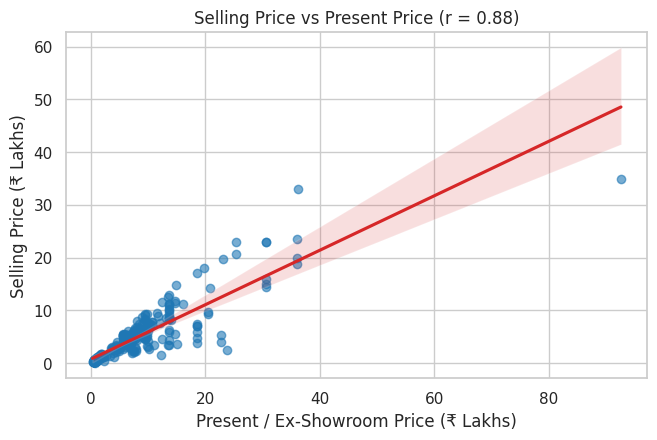

In [18]:
# Screenshot 1 Code:
plt.figure(figsize=(7.5, 4.5))
sns.regplot(data=df, x='Present_Price', y='Selling_Price', color='#1f77b4',
            scatter_kws={'alpha': 0.6}, line_kws={'color': '#d62728'})
plt.title('Selling Price vs Present Price (r = 0.88)')
plt.xlabel('Present / Ex-Showroom Price (₹ Lakhs)')
plt.ylabel('Selling Price (₹ Lakhs)')
plt.show()

/tmp/ipykernel_2565/2810109978.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='Fuel_Type', ax=axes[0], palette=['#3498db', '#e74c3c', '#2ecc71'])
/tmp/ipykernel_2565/2810109978.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='Transmission', ax=axes[1], palette=['#9b59b6', '#f39c12'])


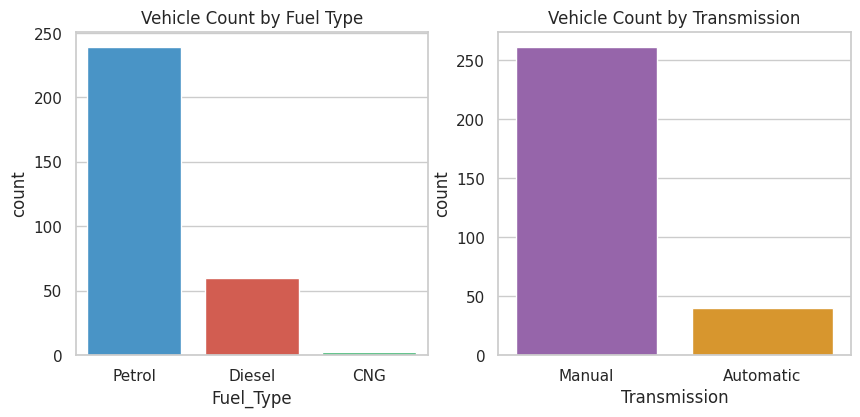

In [19]:
# Screenshot 2 Code:
fig, axes = plt.subplots(1, 2, figsize=(10, 4.2))
sns.countplot(data=df, x='Fuel_Type', ax=axes[0], palette=['#3498db', '#e74c3c', '#2ecc71'])
axes[0].set_title('Vehicle Count by Fuel Type')

sns.countplot(data=df, x='Transmission', ax=axes[1], palette=['#9b59b6', '#f39c12'])
axes[1].set_title('Vehicle Count by Transmission')
plt.show()

/tmp/ipykernel_2565/3396761854.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_vehicles.index, y=top_vehicles.values, palette='Blues_r')


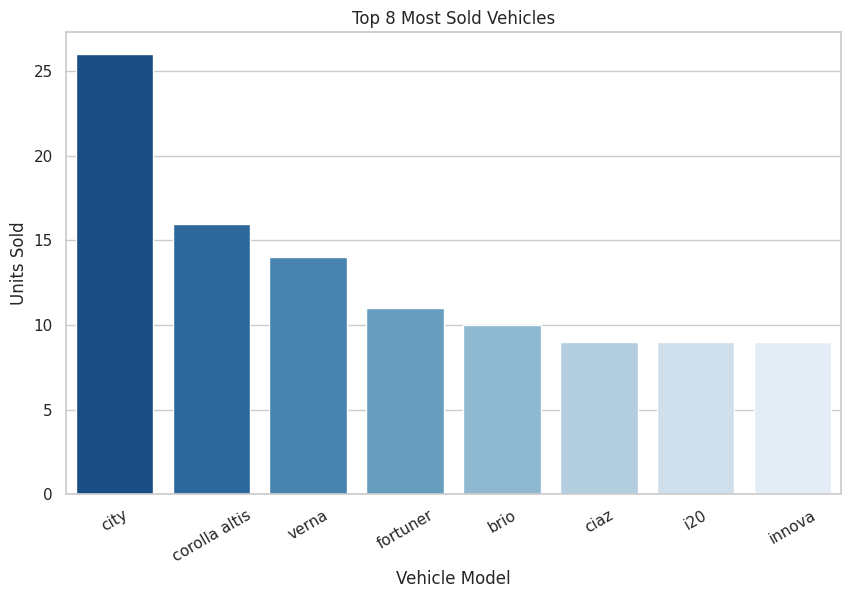

In [20]:
# Screenshot 3 Code:
top_vehicles = df['Car_Name'].value_counts().head(8)
sns.barplot(x=top_vehicles.index, y=top_vehicles.values, palette='Blues_r')
plt.title('Top 8 Most Sold Vehicles')
plt.xlabel('Vehicle Model')
plt.ylabel('Units Sold')
plt.xticks(rotation=30)
plt.show()

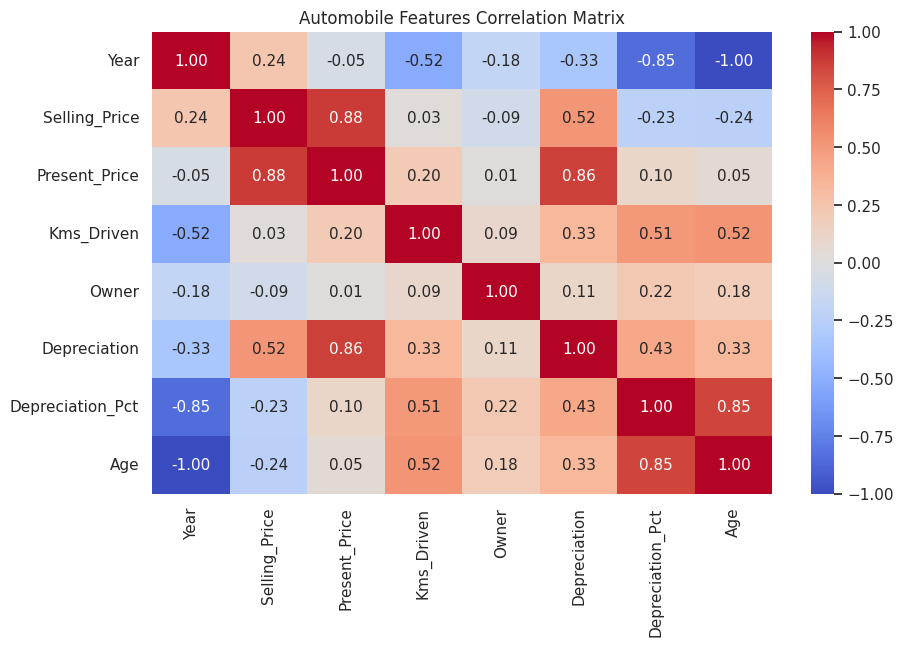

In [21]:
# Screenshot 4 Code:
numeric_cols = df.select_dtypes(include=[np.number])
sns.heatmap(numeric_cols.corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Automobile Features Correlation Matrix')
plt.show()